In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
df=pd.read_csv('data_jobs.csv')
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_India=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='India')].copy()

In [3]:
df_DA_India=df_DA_India.dropna(subset=['salary_year_avg'])

df_DA_India_exploded=df_DA_India.explode('job_skills')

df_DA_India_exploded[['salary_year_avg' , 'job_skills']].head(5)

,salary_year_avg,job_skills
11412,50400.0,python
11412,50400.0,sql
11412,50400.0,aws
11412,50400.0,azure
11412,50400.0,excel


In [4]:
df_DA_skills=df_DA_India_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)
df_DA_skills=df_DA_skills.rename(columns={'count' : 'skill_count' , 'median':'median_salary'})
DA_job_count=len(df_DA_India)
df_DA_skills['skill_percent']=df_DA_skills['skill_count'] / DA_job_count * 100

skill_percent=5
df_DA_skills_high_demand=df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,46,96050.00,48.936170
excel,39,98500.00,41.489362
python,36,96050.00,38.297872
tableau,20,108087.50,21.276596
r,18,79200.00,19.148936
power bi,17,111175.00,18.085106
azure,15,93600.00,15.957447
aws,12,79200.00,12.765957
oracle,11,79200.00,11.702128


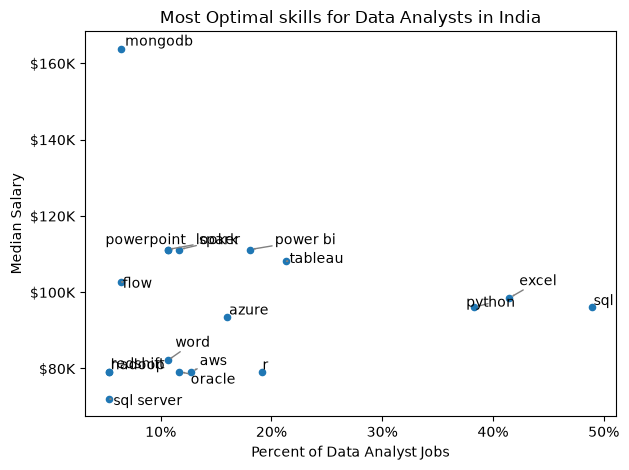

In [5]:
from adjustText import adjust_text
df_DA_skills_high_demand.plot(kind='scatter',x='skill_percent',y='median_salary')

texts=[]
for i,txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i],df_DA_skills_high_demand['median_salary'].iloc[i],txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->' , color ='gray'))

from matplotlib.ticker import PercentFormatter
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos:f'${int (y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary')
plt.title('Most Optimal skills for Data Analysts in India')

plt.tight_layout()
plt.show()


In [6]:
df['job_type_skills'].head(10)

0                                                  NaN
1    {'analyst_tools': ['power bi', 'tableau'], 'pr...
2    {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3    {'cloud': ['aws'], 'libraries': ['tensorflow',...
4    {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
5    {'cloud': ['gcp'], 'programming': ['python', '...
6    {'cloud': ['gcp', 'bigquery'], 'databases': ['...
7    {'cloud': ['gcp', 'azure', 'aws', 'bigquery', ...
8    {'analyst_tools': ['excel', 'powerpoint', 'pow...
9    {'analyst_tools': ['excel'], 'cloud': ['azure'...
Name: job_type_skills, dtype: str

In [8]:
df_technology=df['job_type_skills'].copy()
#remove dupliactes
df_technology=df_technology.drop_duplicates()
#remove NaN values
df_technology=df_technology.dropna()

#combine all dictionaries into one
technology_dict={}
for row in df_technology:
    row_dict=ast.literal_eval(row) # convert string to dict
    for key,value in row_dict.items():
        if key in technology_dict:
            technology_dict[key]+= value
        else:
            technology_dict[key]= value

for key,value in technology_dict.items():
    technology_dict[key]=list(set(value))

technology_dict


{'analyst_tools': ['sas',
  'looker',
  'excel',
  'spss',
  'cognos',
  'splunk',
  'dax',
  'spreadsheet',
  'alteryx',
  'msaccess',
  'microstrategy',
  'nuix',
  'power bi',
  'powerpoint',
  'sap',
  'word',
  'ms access',
  'sharepoint',
  'qlik',
  'tableau',
  'outlook',
  'powerbi',
  'ssis',
  'datarobot',
  'sheets',
  'esquisse',
  'visio',
  'ssrs'],
 'programming': ['c',
  'sass',
  'nosql',
  'sas',
  'mongodb',
  'crystal',
  'ruby',
  'clojure',
  'javascript',
  'kotlin',
  'dart',
  'apl',
  'mongo',
  'ocaml',
  'sql',
  'visual basic',
  'haskell',
  'solidity',
  'groovy',
  'css',
  'erlang',
  'no-sql',
  'visualbasic',
  'shell',
  'lua',
  'rust',
  'lisp',
  'objective-c',
  'scala',
  'r',
  'perl',
  'fortran',
  'go',
  't-sql',
  'swift',
  'f#',
  'c#',
  'bash',
  'c++',
  'powershell',
  'html',
  'cobol',
  'java',
  'vb.net',
  'assembly',
  'elixir',
  'vba',
  'golang',
  'julia',
  'matlab',
  'python',
  'php',
  'typescript',
  'pascal',
  'del

In [10]:
df_technology=pd.DataFrame(list(technology_dict.items()),columns=['technology','skills'])

df_technology=df_technology.explode('skills')
df_technology

,technology,skills
0,analyst_tools,sas
0,analyst_tools,looker
0,analyst_tools,excel
0,analyst_tools,spss
0,analyst_tools,cognos
...,...,...
9,sync,twilio
9,sync,google chat
9,sync,symphony
9,sync,slack


In [13]:
df_plot=df_DA_skills_high_demand.merge(df_technology,left_on='job_skills',right_on='skills')

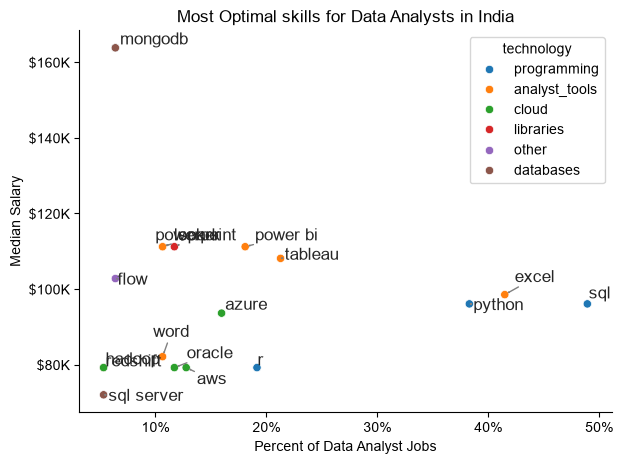

In [14]:
from adjustText import adjust_text
sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

texts=[]
for i,txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i],df_DA_skills_high_demand['median_salary'].iloc[i],txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->' , color ='gray'))

from matplotlib.ticker import PercentFormatter
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos:f'${int (y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary')
plt.title('Most Optimal skills for Data Analysts in India')

plt.tight_layout()
plt.show()